# Conos walkthrough: jointly analysing a panel of samples

**Conos** (Clustering On Network of Samples) analyses a *collection* of
single-cell samples together. Instead of merging all cells into one
matrix, it aligns each pair of samples in a shared space, stitches their
neighbourhoods into one weighted graph, and runs clustering, embedding,
and differential expression on that joint graph. Cells of the same type
connect across samples, while each sample keeps its own structure — so
you can ask “which populations are shared?”, “how do their proportions
differ between conditions?”, and “can I carry annotations from one
sample to the rest?”.

This walkthrough takes the standard workflow end to end on a small panel
of bone-marrow (BM) and cord-blood (CB) samples. For controlling the
alignment (spaces, memory, multimodal data) see the [advanced
tutorial](conos-advanced.ipynb).

## Loading your data

A Conos panel is just a **named list of per-sample objects**, one per
sample, each already processed with
[pagoda2](https://github.com/kharchenkolab/pagoda2) (or Seurat). In
practice you build one object per sample from its count data — for
example:

In [ ]:
library(pagoda2)

# from a 10x CellRanger output folder (contains matrix.mtx / barcodes / features):
s1 <- Pagoda2$from10x("sample1/outs/filtered_feature_bc_matrix")

# from a 10x HDF5 file:
s2 <- Pagoda2$from10xH5("sample2_filtered_feature_bc_matrix.h5")

# or directly from a counts matrix (genes x cells), e.g. one you loaded yourself:
s3 <- Pagoda2$from(my_counts_matrix)

**Cell names must be unique across the whole panel** so that no two
cells (even in different samples) collide.

For this tutorial we use a ready-made example panel of four samples from
the `conosPanel` package
(`install.packages("conosPanel", repos = "https://kharchenkolab.github.io/drat/")`).
Each element is a sparse counts matrix (genes × cells):

In [ ]:
library(conos)
library(pagoda2)

panel <- conosPanel::panel
str(panel, 1)

List of 4
 $ MantonBM1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonBM2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots

To keep the tutorial quick we down-sample each sample to a few hundred
cells; in a real analysis you would use all of them.

In [ ]:
set.seed(1)
panel <- lapply(panel, function(m) m[, sample(ncol(m), 600)])

## Pre-processing each sample

Each sample is turned into a `Pagoda2` object carrying a PCA reduction.
We wrap the two standard steps — variance normalisation and PCA — in a
small helper and apply it to every sample. (`Pagoda2$from()` accepts a
folder, an `.h5`, or a counts matrix as shown above.)

In [ ]:
preprocess <- function(counts) {
  rownames(counts) <- make.unique(rownames(counts))         # de-duplicate any repeated gene symbols
  p <- Pagoda2$from(counts, n.cores = 1, min.cells.per.gene = 0,
                    min.transcripts.per.cell = 0, log.scale = TRUE, verbose = FALSE)
  p$run(steps = c("variance", "pca"), dependencies = "error", verbose = FALSE)
  p
}

samples <- lapply(panel, preprocess)

## Building the joint graph

Create the Conos object from the per-sample objects, then build the
joint alignment graph. `runGraph()` aligns every pair of samples on
reciprocal PCA (`space = "PCA"`, the recommended default) and stitches
the neighbourhoods together; `k` / `k.self` set the inter- and
within-sample neighbourhood sizes.

In [ ]:
con <- Conos$new(samples, n.cores = 1)

In [ ]:
con$runGraph(k = 15, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)

## Joint clustering

Detect clusters as communities on the joint graph (Leiden by default):

In [ ]:
con$runClustering(verbose = FALSE)

## Visualising the joint embedding

Compute a joint 2D embedding (UMAP) and colour it by the detected
clusters:

In [ ]:
con$runEmbedding(method = "UMAP", min.visited.verts = 100, verbose = FALSE)

Warning in uwot(X = X, n_neighbors = n_neighbors, n_components = n_components,
: n_components > number of columns in input data: 2 > 1, this may give poor or
unexpected results

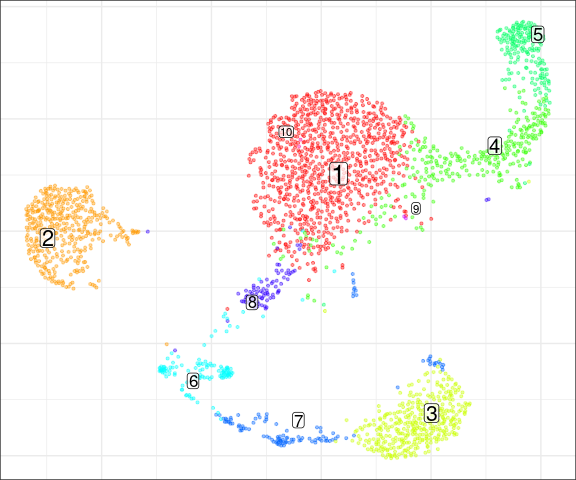

In [ ]:
con$plotGraph(clustering = "leiden")

## Are the samples well mixed?

The key question in any integration: do the samples *overlap* in the
joint embedding (good — the same cell types are aligned across samples),
or do they sit apart (a sign of under-correction or genuinely distinct
populations)? Colour the same embedding by **sample** instead of
cluster:

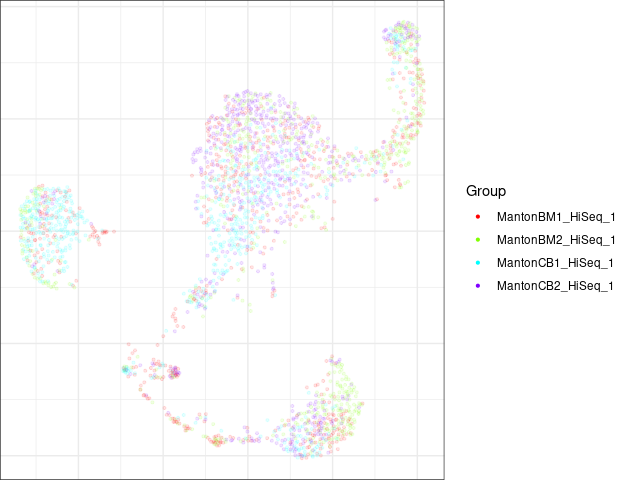

In [ ]:
con$plotGraph(color.by = "sample", mark.groups = FALSE, show.legend = TRUE, alpha = 0.1)

Cells from all four samples are interspersed within each region, so the
populations are well aligned.

## Cluster composition across samples

`plotClusterBarplots()` shows what fraction of each cluster comes from
each sample — useful for spotting clusters that are sample- or
condition-specific (here, differences between bone marrow and cord
blood):

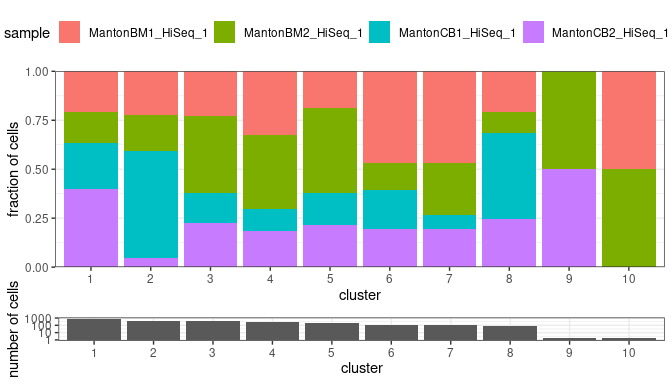

In [ ]:
plotClusterBarplots(con, clustering = "leiden", show.entropy = FALSE)

## A per-sample view

The same joint clustering laid over each sample separately. Because the
clustering is *joint*, seeing the same colours in every panel confirms
the populations are shared rather than sample-specific:

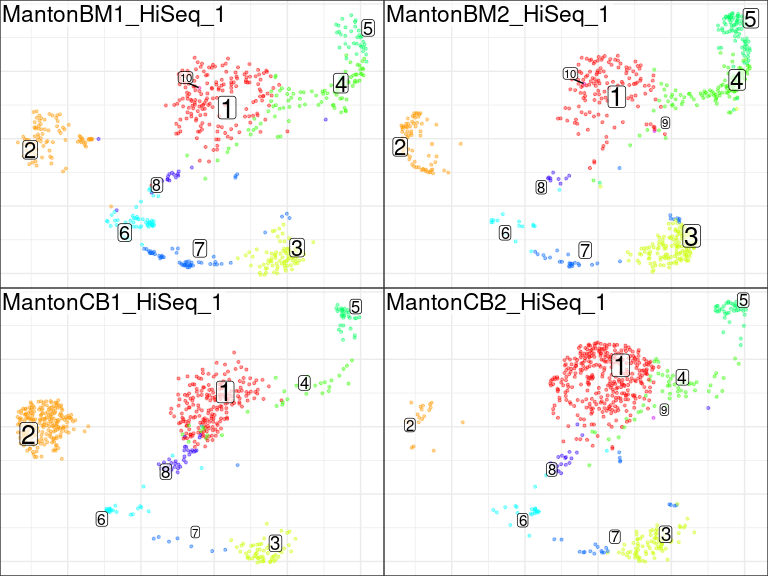

In [ ]:
con$plotPanel(clustering = "leiden", use.common.embedding = TRUE)

## Marker genes

`runMarkers()` finds genes differentially expressed between clusters;
`plotMarkerDotPlot()` shows the top few per cluster (dot size = fraction
of cells expressing, colour = scaled mean expression):

removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.
removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.
removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.
removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.

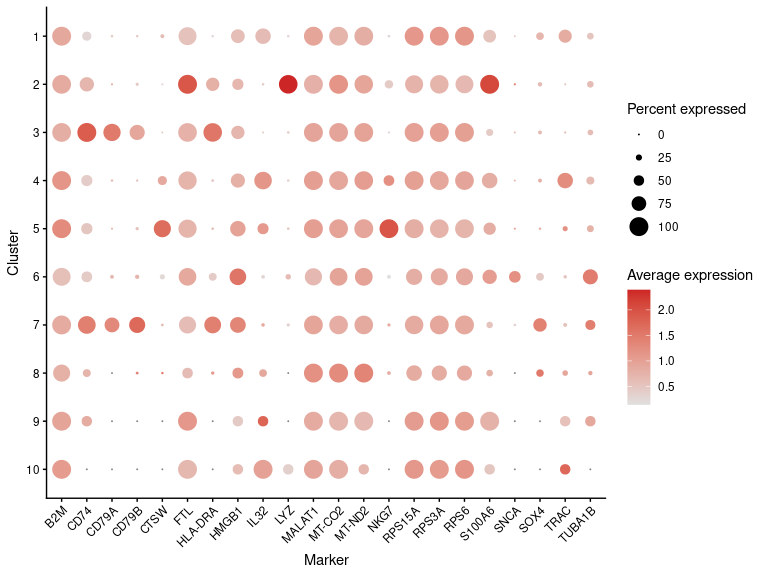

In [ ]:
con$plotMarkerDotPlot(n.genes.per.group = 3)

You can also paint a single gene onto the joint embedding:

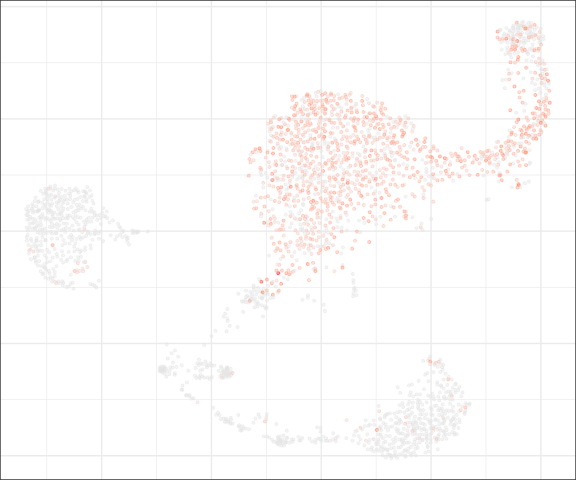

In [ ]:
con$plotGraph(gene = "CD3E")

## Transferring annotations between samples

A common task is to carry cell-type labels from an annotated sample (or
any labelled subset) to the rest. `propagateLabels()` spreads the labels
over the joint graph and returns, per cell, the transferred label and an
uncertainty score. Here we simulate it by labelling a random 40% of
cells and propagating to the rest:

In [ ]:
groups    <- con$clusters$leiden$groups
set.seed(1)
reference <- groups[sample(length(groups), round(0.40 * length(groups)))]
transfer  <- con$propagateLabels(labels = reference, verbose = FALSE)

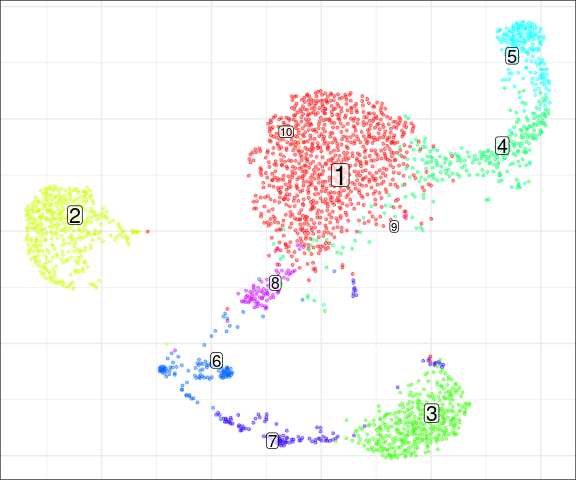

In [ ]:
con$plotGraph(groups = transfer$labels)

`transfer$uncertainty` is a 0–1 score per cell (low = confident) that
you can threshold or plot to flag cells whose transferred label is
ambiguous.

## Recap

The whole standard workflow is four calls on the Conos object:

``` r
con <- Conos$new(samples)
con$runGraph()        # align samples -> joint graph
con$runClustering()   # Leiden communities
con$runEmbedding()    # joint 2D embedding
```

plus `plotGraph()` / `plotPanel()` / `plotClusterBarplots()` to
visualise, `runMarkers()` / `plotMarkerDotPlot()` for markers, and
`propagateLabels()` for annotation transfer. To control the alignment
space, memory, and multimodal data, continue to the [advanced
tutorial](conos-advanced.ipynb).